# End-to-End Regression Pipeline — California Housing

## What you'll learn

How to take **any new tabular dataset** and produce a deployable regression model. We cover every step from raw CSV to saved `.pkl` / `.joblib` artifact, with explanations of *what* to do and *why*.

## The Universal ML Pipeline (template)

```
1. Define the problem    → regression/classification? what does "good" mean?
2. Load the data         → read into a DataFrame
3. EDA                   → shape, types, missing, target distribution, correlations
4. Clean & preprocess    → missing values, outliers, encode categoricals, scale
5. Feature engineering   → create domain features, interactions
6. Train/test split      → BEFORE fitting any transformer
7. Build a Pipeline      → preprocessor + model in ONE object (no leakage)
8. Baseline model        → simple, untuned — the bar to beat
9. Try better models     → linear, tree, ensemble
10. Cross-validation     → reliable score estimate
11. Hyperparameter tune  → GridSearchCV / RandomizedSearchCV
12. Evaluate on test     → ONCE, at the end
13. Inspect errors       → residual plots, worst predictions
14. Explain the model    → feature importance, SHAP
15. Save the artifact    → joblib (recommended) + pickle, with metadata
16. Reload & predict     → confirm artifact works end-to-end
```

**Why pick California Housing?** It's a classic regression dataset bundled with sklearn — no download needed, mixed feature types, mild non-linearity, and a clear business meaning (predict median house value).

---

## Step 0: Imports — every library you'll need

**Why up front?** If a missing import would fail mid-notebook, you'd lose progress. Front-loading them is also a checklist of what tools you'll use.

In [2]:
import os, json, pickle, joblib
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
print('Imports OK')

Imports OK


## Step 1: Define the problem

**Always answer these BEFORE writing code:**
1. **What are we predicting?** — Median house value (continuous → regression).
2. **Who uses it?** — A real-estate pricing tool.
3. **What metric matters?** — RMSE in $100k units (MAE is more interpretable; R² shows variance explained).
4. **Acceptance criterion?** — Beat the mean baseline; aim for R² > 0.7 on test.
5. **Data constraints?** — None unusual; numeric features only.

Skipping this step is the #1 reason ML projects fail.

## Step 2: Load the data

**Why a DataFrame?** Pandas gives you `.info()`, `.describe()`, `.isna()`, easy plotting — much faster iteration than NumPy arrays. Convert to NumPy only when handing off to sklearn at the very end.

In [3]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
df.rename(columns={'MedHouseVal': 'target'}, inplace=True)
print(f'Shape: {df.shape}')
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Exploratory Data Analysis (EDA)

**What you're looking for:**
1. **Types** — numeric vs categorical; need different preprocessing.
2. **Missing values** — how much, in which columns.
3. **Target distribution** — skewed? outliers? does it need transformation (e.g., log)?
4. **Feature distributions** — outliers, skewness, units.
5. **Correlations** — multicollinearity, predictive features.

**Why:** EDA tells you *what preprocessing the data needs* — you don't guess; you let the data tell you.

In [4]:
print('Types and missing:')
print(df.dtypes)
print('\nMissing per column:')
print(df.isna().sum())
print('\nDescribe:')
df.describe().round(2)

Types and missing:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object

Missing per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

Describe:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


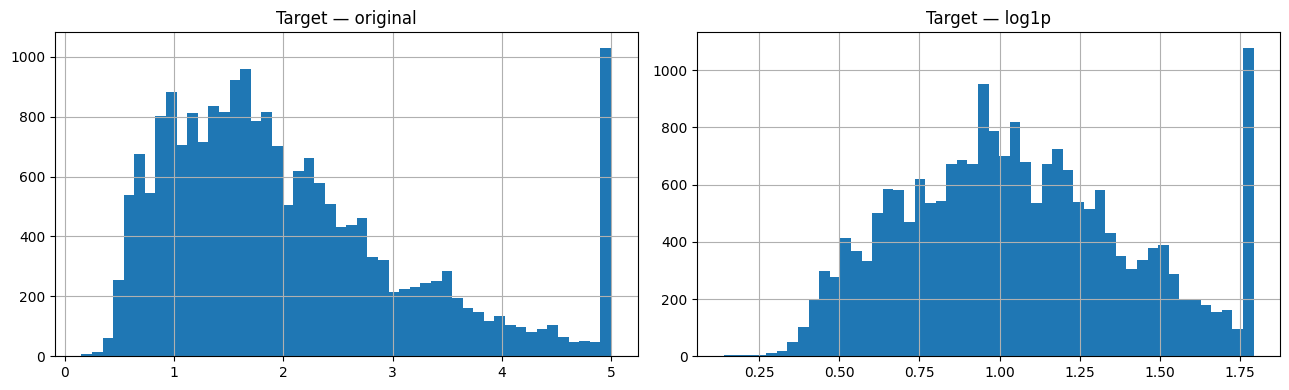

Skewness original: 0.978  |  after log1p: 0.276
Target is right-skewed and capped at ~5. We could log-transform, but for tree models it's not necessary.


In [5]:
# Target distribution + log-transform check
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df['target'].hist(bins=50, ax=ax[0]); ax[0].set_title('Target — original')
np.log1p(df['target']).hist(bins=50, ax=ax[1]); ax[1].set_title('Target — log1p')
plt.tight_layout(); plt.show()
print(f'Skewness original: {df.target.skew():.3f}  |  after log1p: {np.log1p(df.target).skew():.3f}')
print('Target is right-skewed and capped at ~5. We could log-transform, but for tree models it\'s not necessary.')

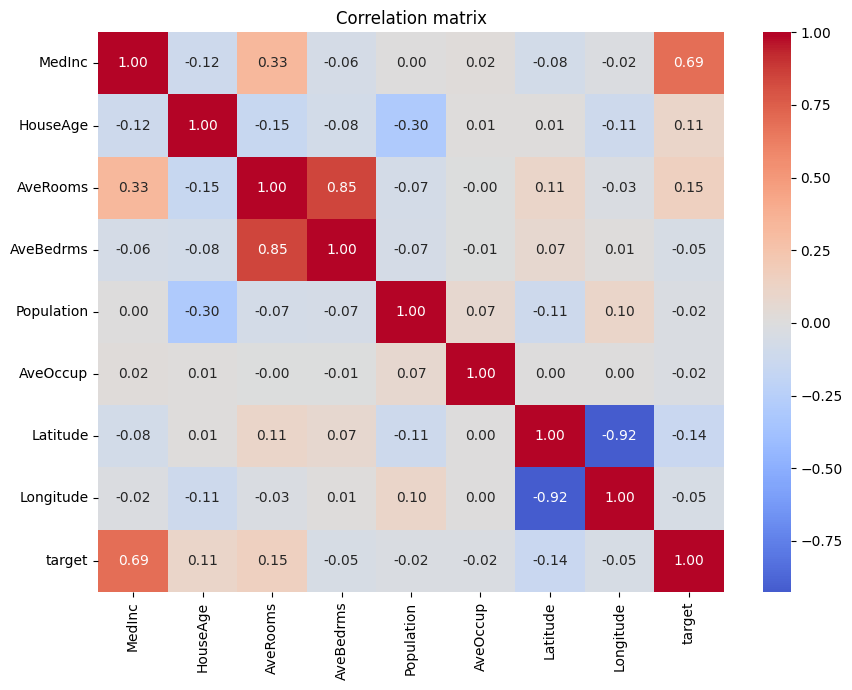

Look at the target row — MedInc has the strongest correlation. Latitude/Longitude correlate with location effects.


In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix'); plt.tight_layout(); plt.show()
print('Look at the target row — MedInc has the strongest correlation. Latitude/Longitude correlate with location effects.')

## Step 4: Clean & engineer features

**Why before splitting?** *Cleaning* (drop duplicate rows, fix obvious errors) is fine before splitting. *Fitting transformers* (imputer, scaler) is NOT — it leaks test info into training. We'll do that inside a Pipeline.

**Domain features** for housing:
- `rooms_per_household = AveRooms` — already there in different form.
- `bedrooms_ratio = AveBedrms / AveRooms`.
- `population_per_household = Population / AveOccup`.

These often outperform raw features because they encode meaningful ratios.

In [7]:
df['bedrooms_ratio']         = df['AveBedrms'] / df['AveRooms']
df['rooms_per_person']       = df['AveRooms']  / df['AveOccup']
df['log_population']         = np.log1p(df['Population'])

# Drop obvious duplicates if any
before = len(df); df = df.drop_duplicates(); after = len(df)
print(f'Dropped {before - after} duplicate rows.')

# Outlier inspection on target — rows where target is exactly the cap (5.0) are suspicious
capped = (df['target'] == df['target'].max()).sum()
print(f'Rows at the target cap (likely censored): {capped}')
# We keep them — removing rows can introduce bias. Note for later in error analysis.

df.head(3)

Dropped 0 duplicate rows.
Rows at the target cap (likely censored): 965


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target,bedrooms_ratio,rooms_per_person,log_population
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0.146591,2.732919,5.777652
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.155797,2.956685,7.784057
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.129516,2.957661,6.208590


## Step 5: Train / Test Split — BEFORE any fitting

**The single most important rule in ML:** the test set must be untouched until the end. Fit transformers only on training data; apply them to test.

Why split now? Because everything from this point on (imputer, scaler, model selection, tuning) is optimization that can leak test info if done on the full dataset.

For regression: simple random split. For classification: use `stratify=y`. For time series: `TimeSeriesSplit`.

In [8]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Feature columns ({len(X.columns)}): {list(X.columns)}')

Train: (16512, 11)  |  Test: (4128, 11)
Feature columns (11): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'bedrooms_ratio', 'rooms_per_person', 'log_population']


## Step 6: Build the Preprocessing Pipeline

**Why a `Pipeline`?**
1. Prevents leakage: each transformer is `fit` only on the training fold during CV.
2. Reproducibility: one object holds the whole pipeline → you save and reload one thing.
3. Less code to maintain — apply transformations consistently at train and inference time.

**For California Housing:** all features are numeric, so we only need impute + scale. If we had categorical features, we'd add a parallel branch via `ColumnTransformer`.

In [9]:
numeric_cols = X_train.columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # robust to outliers
    ('scaler',  StandardScaler()),                  # only matters for linear models
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    # ('cat', categorical_pipe, categorical_cols),  # would go here if we had categoricals
])

print('Preprocessor built. Note: NOT fit yet — Pipeline fits inside CV/train.')

Preprocessor built. Note: NOT fit yet — Pipeline fits inside CV/train.


## Step 7: Baseline model

**Why a baseline?** It defines the bar to beat. If your fancy model can't beat "predict the mean", something is wrong. Always know your baseline.

In [10]:
from sklearn.dummy import DummyRegressor

baseline = Pipeline([('prep', preprocessor), ('model', DummyRegressor(strategy='mean'))])
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
print(f'Baseline (predict-the-mean):')
print(f'  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'  MAE  = {mean_absolute_error(y_test, y_pred):.4f}')
print(f'  R²   = {r2_score(y_test, y_pred):.4f}   (≈0 by construction)')

Baseline (predict-the-mean):
  RMSE = 1.1449
  MAE  = 0.9061
  R²   = -0.0002   (≈0 by construction)


## Step 8: Try several models

**Why try multiple?** Linear vs tree-based models capture very different patterns. Trying 3–4 quickly tells you which family suits the data without wasting time tuning the wrong one.

**Use cross-validation**, not the test set, to compare. Test set is sacred until the end.

In [11]:
candidates = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in candidates.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmses = -scores
    rows.append({'model': name, 'cv_rmse_mean': rmses.mean(), 'cv_rmse_std': rmses.std()})
    print(f'{name:20s} | CV RMSE = {rmses.mean():.4f} ± {rmses.std():.4f}')

leaderboard = pd.DataFrame(rows).sort_values('cv_rmse_mean')
print('\nLeaderboard:')
print(leaderboard.to_string(index=False))

Linear Regression    | CV RMSE = 0.6814 ± 0.0221
Ridge                | CV RMSE = 0.6814 ± 0.0220
Random Forest        | CV RMSE = 0.5125 ± 0.0112
Gradient Boosting    | CV RMSE = 0.5007 ± 0.0111

Leaderboard:
            model  cv_rmse_mean  cv_rmse_std
Gradient Boosting      0.500655     0.011128
    Random Forest      0.512504     0.011232
            Ridge      0.681400     0.022041
Linear Regression      0.681410     0.022063


## Step 9: Hyperparameter tuning (on the winner)

**Strategy:** tune the most-impactful 2–3 hyperparameters first, then refine.

**For Gradient Boosting:** `learning_rate`, `n_estimators`, `max_depth` are the most influential.

Use `GridSearchCV` for a small grid; `RandomizedSearchCV` for a wide search space.

In [12]:
best_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

param_grid = {
    'model__n_estimators'  : [200, 400],
    'model__learning_rate' : [0.05, 0.1],
    'model__max_depth'     : [3, 5],
}

grid = GridSearchCV(
    best_pipe, param_grid,
    cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV RMSE: {-grid.best_score_:.4f}')
final_model = grid.best_estimator_

Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 400}
Best CV RMSE: 0.4659


## Step 10: Final evaluation on the test set (ONCE)

This is the only time you touch the test set. Reporting CV scores as if they were test scores is a common mistake.

In [13]:
y_pred = final_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print('Final test metrics')
print(f'  RMSE = {rmse:.4f}  (in $100k units → ~${rmse*1e5:,.0f})')
print(f'  MAE  = {mae:.4f}')
print(f'  R²   = {r2:.4f}')

Final test metrics
  RMSE = 0.4572  (in $100k units → ~$45,720)
  MAE  = 0.2983
  R²   = 0.8405


## Step 11: Inspect errors — predicted vs actual + residuals

**Why:** numeric metrics hide where the model breaks. Plots tell you whether errors are random (good) or structured (bias to fix).

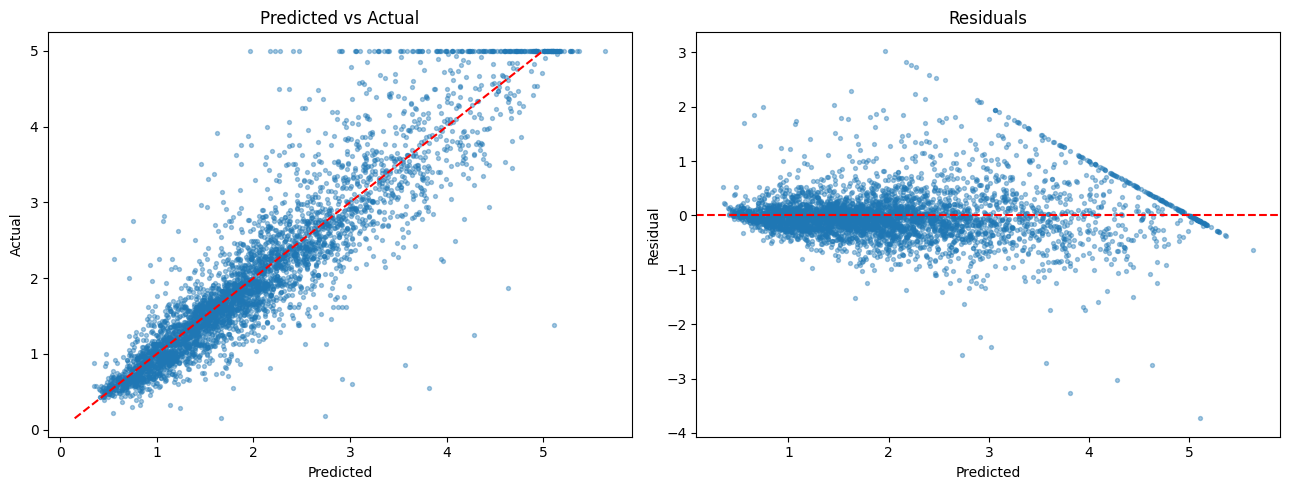

Look for patterns: a curve in residuals → underfit; fan-shape → heteroscedasticity.
Notice errors at the cap (target=5.0) — censored data we flagged earlier.


In [14]:
residuals = y_test - y_pred
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_pred, y_test, s=8, alpha=0.4)
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, 'r--')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual'); ax[0].set_title('Predicted vs Actual')

ax[1].scatter(y_pred, residuals, s=8, alpha=0.4)
ax[1].axhline(0, color='red', ls='--')
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('Residual'); ax[1].set_title('Residuals')
plt.tight_layout(); plt.show()
print('Look for patterns: a curve in residuals → underfit; fan-shape → heteroscedasticity.')
print('Notice errors at the cap (target=5.0) — censored data we flagged earlier.')

## Step 12: Explain the model

**Why:** stakeholders want to know *why* a prediction is what it is. Permutation importance is unbiased and model-agnostic.

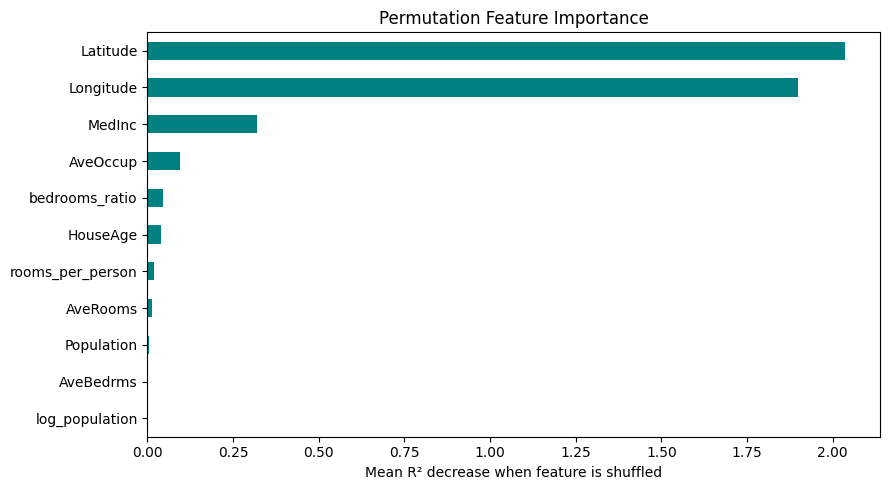

In [15]:
perm = permutation_importance(final_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
imp.plot.barh(color='teal', figsize=(9, 5))
plt.xlabel('Mean R² decrease when feature is shuffled')
plt.title('Permutation Feature Importance')
plt.tight_layout(); plt.show()

## Step 13: Save the artifact (Pickle + Joblib + metadata)

**Why both formats?** Joblib is faster and smaller for sklearn (compresses NumPy arrays); pickle is built-in and universal. We save both for completeness — joblib is the default choice in production.

**Always save metadata next to the model.** Six months from now you'll thank yourself.

In [16]:
import sklearn, sys

ART_DIR = 'artifacts_regression'
os.makedirs(ART_DIR, exist_ok=True)

# Pickle
with open(f'{ART_DIR}/model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Joblib (preferred — compressed)
joblib.dump(final_model, f'{ART_DIR}/model.joblib', compress=3)

metadata = {
    'model_name'   : 'california-housing-gbm',
    'version'      : '1.0.0',
    'trained_at'   : datetime.utcnow().isoformat() + 'Z',
    'feature_names': X_train.columns.tolist(),
    'target_name'  : 'median_house_value_in_100k_usd',
    'metrics'      : {'test_rmse': float(rmse), 'test_mae': float(mae), 'test_r2': float(r2)},
    'best_params'  : {k: (v if isinstance(v, (int, float, str)) else str(v)) for k, v in grid.best_params_.items()},
    'env': {
        'python'  : sys.version.split()[0],
        'sklearn' : sklearn.__version__,
        'numpy'   : np.__version__,
        'pandas'  : pd.__version__,
    },
}
with open(f'{ART_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved: pickle ({os.path.getsize(f'{ART_DIR}/model.pkl'):,} bytes), " \
      f"joblib ({os.path.getsize(f'{ART_DIR}/model.joblib'):,} bytes)")
print(json.dumps(metadata, indent=2))

Saved: pickle (1,555,568 bytes), joblib (739,362 bytes)
{
  "model_name": "california-housing-gbm",
  "version": "1.0.0",
  "trained_at": "2026-05-31T19:11:40.753982Z",
  "feature_names": [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude",
    "bedrooms_ratio",
    "rooms_per_person",
    "log_population"
  ],
  "target_name": "median_house_value_in_100k_usd",
  "metrics": {
    "test_rmse": 0.45720133769514526,
    "test_mae": 0.29834325727416633,
    "test_r2": 0.84048257707236
  },
  "best_params": {
    "model__learning_rate": 0.1,
    "model__max_depth": 5,
    "model__n_estimators": 400
  },
  "env": {
    "python": "3.10.11",
    "sklearn": "1.2.2",
    "numpy": "1.23.5",
    "pandas": "1.4.4"
  }
}


## Step 14: Reload & predict — the smoke test

**Why:** confirms the artifact actually works end-to-end. Catches issues like missing dependencies or pipeline bugs that only show up at load time.

In [17]:
loaded = joblib.load(f'{ART_DIR}/model.joblib')

# Build a single-row prediction the way a real API would
sample = X_test.iloc[[0]]
pred = loaded.predict(sample)[0]
actual = y_test.iloc[0]
print(f'Sample input  : {sample.iloc[0].to_dict()}')
print(f'Predicted     : ${pred * 1e5:,.0f}')
print(f'Actual        : ${actual * 1e5:,.0f}')
print(f'Difference    : ${abs(pred - actual) * 1e5:,.0f}')

Sample input  : {'MedInc': 1.6812, 'HouseAge': 25.0, 'AveRooms': 4.192200557103064, 'AveBedrms': 1.0222841225626742, 'Population': 1392.0, 'AveOccup': 3.8774373259052926, 'Latitude': 36.06, 'Longitude': -119.01, 'bedrooms_ratio': 0.24385382059800667, 'rooms_per_person': 1.08117816091954, 'log_population': 7.239214973779806}
Predicted     : $51,810
Actual        : $47,700
Difference    : $4,110


---
## Pipeline Recap — the template you can reuse

When you get a new regression dataset, repeat these 14 steps. The decisions you make at each step depend on the data, but the structure is always the same.

| # | Step | Key decision |
|---|------|--------------|
| 1 | Define problem | Metric? Acceptance? |
| 2 | Load data | Pandas DataFrame |
| 3 | EDA | Types, missing, target dist, correlations |
| 4 | Clean & engineer | Drop dups, domain features |
| 5 | Split | `train_test_split` with `random_state` |
| 6 | Build pipeline | Impute → scale → (encode if cat) |
| 7 | Baseline | DummyRegressor — bar to beat |
| 8 | Try models | 3–4 different families |
| 9 | Tune winner | GridSearchCV on key params |
| 10 | Final test | RMSE / MAE / R² on test set, ONCE |
| 11 | Error analysis | Residual plots |
| 12 | Explain | Permutation importance |
| 13 | Save | joblib + pickle + JSON metadata |
| 14 | Reload | Smoke test |

## Things to swap when you have a different dataset

| If your data has... | Add this step |
|---------------------|---------------|
| Categorical features | `OneHotEncoder` branch in `ColumnTransformer` |
| Lots of missing values | Choose imputer strategy (median for skewed, KNN, model-based) |
| Severe outliers | `RobustScaler` or capping |
| Highly skewed target | `np.log1p` transform; predict log; `np.expm1` to invert |
| Time component | Use `TimeSeriesSplit`, lag features |
| Class imbalance (classification) | See the classification notebook |
| Text columns | TF-IDF / embeddings — see classification notebook |
| Very large dataset | Switch to LightGBM/XGBoost; sample for tuning |